# 🏦 Modelo v4 — Teoría de Colas para Agencias Bancarias
## M/M/s → M/G/s | Optimización · Simulación Monte Carlo · Análisis de Sensibilidad

**Objetivo:** Dimensionamiento óptimo de auxiliares de operaciones por agencia y franja horaria,
minimizando el costo total mientras se garantizan niveles de servicio aceptables.

---
### 📋 Flujo del modelo
```
Datos (df.csv + dist_agencias.csv)
  → μ y C_s² ponderados por hora
    → M/M/s por hora con restricciones operativas
      → Extensión M/G/s (Allen-Cunneen)
        → Optimización de servidores por hora
          → Consolidación por turnos (T1: 09-14 | T2: 14-18)
            → Simulación Monte Carlo (validación)
              → Análisis de Sensibilidad
                → Outputs: tabla hora / turno / decisiones
```

## PASO 1 — Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
import time
from math import factorial
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 250)

# ── Parámetros globales del modelo ──────────────────────────────────────────
WQ_MAX_MIN   = 5.0     # Wq máximo aceptable (minutos)
RHO_MAX      = 0.85    # Utilización máxima aceptable
ALPHA        = 2.5     # Factor de penalización (α ∈ [2, 3])
N_SIM        = 3_000   # Iteraciones Monte Carlo por escenario
MAX_SERVERS  = 15      # Límite superior de búsqueda en optimización
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

print('✅ Librerías y parámetros cargados correctamente')
print(f'   Wq_max = {WQ_MAX_MIN} min | ρ_max = {RHO_MAX} | α = {ALPHA} | Simulaciones = {N_SIM:,}')

✅ Librerías y parámetros cargados correctamente
   Wq_max = 5.0 min | ρ_max = 0.85 | α = 2.5 | Simulaciones = 3,000


## PASO 2 — Carga de datos

In [2]:
df   = pd.read_csv('df.csv')
dist = pd.read_csv('dist_agencias.csv')

print('=== df.csv ===')
print(f'Dimensiones: {df.shape}')
print(df.to_string(index=False))
print()
print('=== dist_agencias.csv ===')
print(f'Dimensiones: {dist.shape}')
print(dist[['agencia','tipo_ope']].drop_duplicates().to_string(index=False))

=== df.csv ===
Dimensiones: (30, 6)
                              agencia                hora  lambda  servidores      Cs      Cq
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 16:00:00 - 16:59:59 59.1100           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 17:00:00 - 17:59:59 65.2800           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES 

## PASO 3 — Parámetros de servicio por tipo de operación

In [3]:
# Tiempo promedio de servicio por tipo de operación (minutos)
T_SERVICIO = {
    'DEPOSITO':                         3.8,
    'COBRANZA LOCALES OTRAS AGENCIAS':  2.5,
    'COBRANZAS':                        3.5,
    'RETIRO':                           3.0,
    'DESEMBOLSO':                       20.5,
    'APERTURA':                        12.0
}

# Varianza del tiempo de servicio (minutos²)
# Operaciones simples → baja varianza | complejas → alta varianza
VAR_SERVICIO = {
    'DEPOSITO':                         1.0,
    'COBRANZA LOCALES OTRAS AGENCIAS':  3.5,
    'COBRANZAS':                        1.5,
    'RETIRO':                           1.5,
    'DESEMBOLSO':                      7.0,
    'APERTURA':                        5.0
}


dist['t_s']   = dist['tipo_ope'].map(T_SERVICIO)
dist['var_s'] = dist['tipo_ope'].map(VAR_SERVICIO)

print('Parámetros de servicio asignados:')
resumen = dist[['tipo_ope','t_s','var_s']].drop_duplicates('tipo_ope').copy()
resumen['mu_individual'] = (60 / resumen['t_s']).round(2)
resumen['C_s2']          = (resumen['var_s'] / resumen['t_s']**2).round(3)
print(resumen.to_string(index=False))

Parámetros de servicio asignados:
                       tipo_ope     t_s  var_s  mu_individual   C_s2
                       DEPOSITO  3.8000 1.0000        15.7900 0.0690
COBRANZA LOCALES OTRAS AGENCIAS  2.5000 3.5000        24.0000 0.5600
                      COBRANZAS  3.5000 1.5000        17.1400 0.1220
                         RETIRO  3.0000 1.5000        20.0000 0.1670
                     DESEMBOLSO 20.5000 7.0000         2.9300 0.0170
                       APERTURA 12.0000 5.0000         5.0000 0.0350


## PASO 4 — Análisis Exploratorio de Datos (EDA)

In [4]:
print('=== Estadísticas de demanda (λ) por agencia ===')
print(df.groupby('agencia')['lambda'].describe().round(2))
print()
print('=== Configuración actual de servidores ===')
print(df.groupby('agencia')['servidores'].describe().round(2))
print()
print('=== Costos por agencia ===')
print(df.groupby('agencia')[['Cs','Cq']].first().round(2))

=== Estadísticas de demanda (λ) por agencia ===
                                        count    mean     std     min     25%     50%     75%     max
agencia                                                                                              
AG. CIUDAD UNIVERSITARIA              10.0000 49.9800 14.8800 24.0000 38.8200 50.8200 62.5500 67.8300
AG. OPEN SAN CARLOS                   10.0000 29.7900  8.5300 20.0800 23.4700 26.5700 36.4400 46.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 10.0000 47.1700 13.9900 23.4500 37.1200 47.3600 59.0600 65.2800

=== Configuración actual de servidores ===
                                        count   mean    std    min    25%    50%    75%    max
agencia                                                                                       
AG. CIUDAD UNIVERSITARIA              10.0000 6.0000 0.0000 6.0000 6.0000 6.0000 6.0000 6.0000
AG. OPEN SAN CARLOS                   10.0000 4.0000 0.0000 4.0000 4.0000 4.0000 4.0000 4.0000
AG.PARQUE DE LAS F

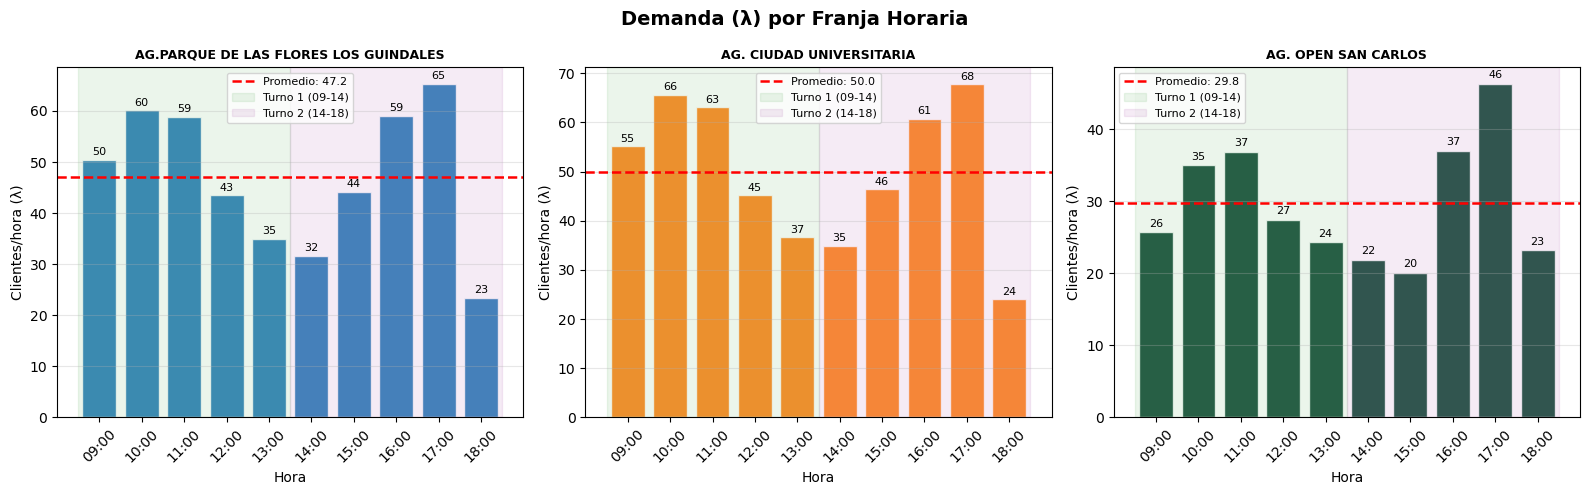

In [10]:
cols_horas = [c for c in dist.columns if ':' in c]
agencias   = df['agencia'].unique()
COLORES    = ['#1f77b4', '#ff7f0e', '#06402B']

agencias

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Demanda (λ) por Franja Horaria', fontsize=14, fontweight='bold')

for ax, agencia, color in zip(axes, agencias, COLORES):
    sub  = df[df['agencia'] == agencia].copy()
    horas = [h[:5] for h in sub['hora']]
    bars  = ax.bar(horas, sub['lambda'], color=color, edgecolor='white', alpha=0.85)
    ax.axhline(sub['lambda'].mean(), color='red', linestyle='--', lw=1.8,
               label=f"Promedio: {sub['lambda'].mean():.1f}")
    ax.axvspan(-0.5, 4.5, alpha=0.08, color='green', label='Turno 1 (09-14)')
    ax.axvspan(4.5, 9.5, alpha=0.08, color='purple', label='Turno 2 (14-18)')
    ax.set_title(agencia[:40], fontsize=9, fontweight='bold')
    ax.set_xlabel('Hora')
    ax.set_ylabel('Clientes/hora (λ)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, sub['lambda']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.0f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
# plt.savefig('eda_demanda.png', dpi=130, bbox_inches='tight')
plt.show()
# print('✅ Gráfico guardado: eda_demanda.png')

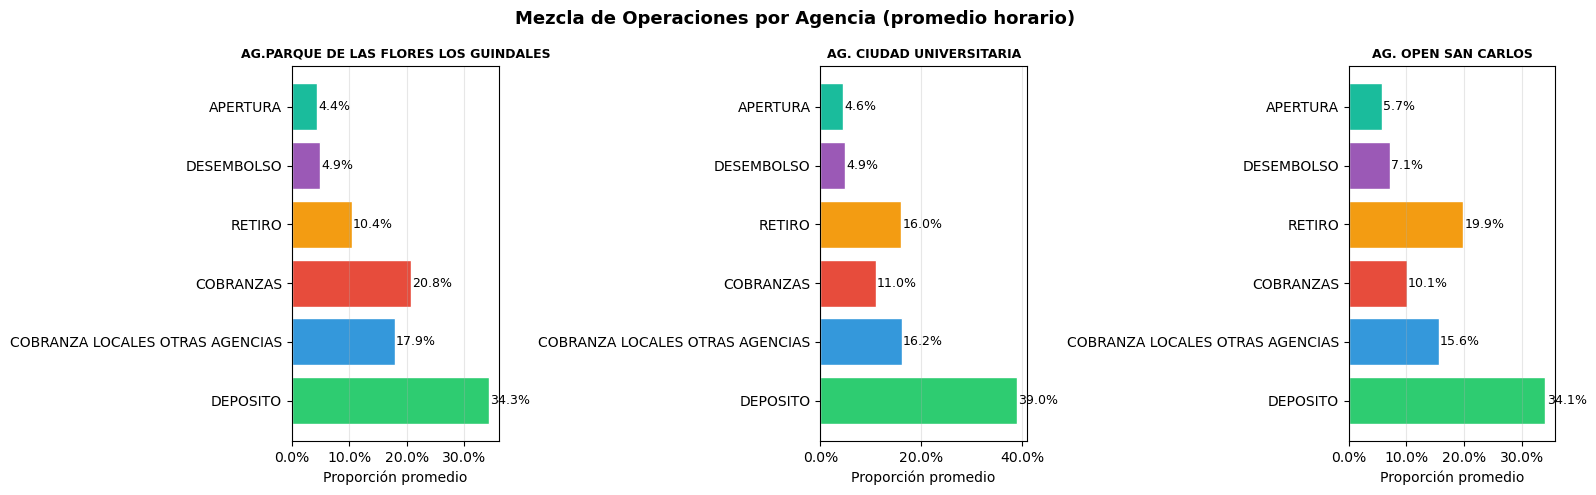

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mezcla de Operaciones por Agencia (promedio horario)', fontsize=13, fontweight='bold')
PALETTE = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#1abc9c']

for ax, agencia in zip(axes, agencias):
    sub = dist[dist['agencia'] == agencia].copy()
    sub['prop_media'] = sub[cols_horas].mean(axis=1)
    bars = ax.barh(sub['tipo_ope'], sub['prop_media'], color=PALETTE[:len(sub)], edgecolor='white')
    for bar, val in zip(bars, sub['prop_media']):
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=9)
    ax.set_title(agencia[:40], fontsize=9, fontweight='bold')
    ax.set_xlabel('Proporción promedio')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
# plt.savefig('eda_operaciones.png', dpi=130, bbox_inches='tight')
plt.show()
# print('✅ Gráfico guardado: eda_operaciones.png')

## PASO 5 — Cálculo de μ ponderado y C_s² por hora

**Fórmulas:**
```
E[T]    = Σ p_k(hora) × t_k          # tiempo promedio ponderado (min)
μ       = 60 / E[T]                   # clientes/hora por servidor
E[T²]   = Σ p_k × (Var_k + t_k²)     # ley de expectativas totales
Var[T]  = E[T²] - E[T]²
C_s²    = Var[T] / E[T]²              # coeficiente de variación al cuadrado
```

In [20]:
def calcular_mu_C_s2(df_base, dist_df, cols_horas):
    """Calcula μ y C_s² ponderados por mezcla de operaciones para cada (agencia, hora)."""
    rows = []
    for _, row in df_base.iterrows():
        agencia = row['agencia']
        hora    = row['hora']
        d       = dist_df[dist_df['agencia'] == agencia]

        if hora not in d.columns:
            rows.append({'agencia': agencia, 'hora': hora, 'mu': np.nan, 'C_s2': np.nan, 'E_T': np.nan})
            continue

        probs = d[hora].values.astype(float)
        ts    = d['t_s'].values.astype(float)
        var_s = d['var_s'].values.astype(float)
        total = probs.sum()

        if total == 0 or np.isnan(total):
            rows.append({'agencia': agencia, 'hora': hora, 'mu': np.nan, 'C_s2': np.nan, 'E_T': np.nan})
            continue

        E_T   = np.dot(probs, ts) / total
        E_T2  = np.dot(probs, var_s + ts**2) / total
        Var_T = max(E_T2 - E_T**2, 0)
        C_s2  = Var_T / E_T**2 if E_T > 0 else np.nan
        mu    = 60.0 / E_T    if E_T > 0 else np.nan
        rows.append({'agencia': agencia, 'hora': hora, 'mu': mu, 'C_s2': C_s2, 'E_T': E_T})

    return pd.DataFrame(rows)


mu_df = calcular_mu_C_s2(df, dist, cols_horas)
df2   = df.merge(mu_df, on=['agencia','hora'], how='left')

print('μ y C_s² calculados por agencia-hora:')
print(df2[['agencia','hora','lambda','servidores','mu','C_s2','E_T']].to_string(index=False))

μ y C_s² calculados por agencia-hora:
                              agencia                hora  lambda  servidores      mu   C_s2    E_T
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5 14.1281 0.7553 4.2468
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5 13.5873 0.8139 4.4159
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5 13.4320 0.8414 4.4670
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5 12.9217 0.8815 4.6433
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5 13.1024 0.8527 4.5793
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5 13.3653 0.8597 4.4892
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5 13.7451 0.7788 4.3652
AG.PARQUE DE LAS FLORES LOS GUINDALES 16:00:00 - 16:59:59 59.1100           5 13.5851 0.8510 4.4166
AG.PARQUE DE LAS FLORES LOS GUINDALES 17:00:00 - 17:59:59 65.2

## PASO 6 — Modelamiento M/M/s con restricciones operativas

**Restricciones obligatorias:**
- ρ = λ/(s×μ) < 1 — estabilidad del sistema
- Wq ≤ 5 minutos — nivel de servicio
- ρ ≤ 0.85 — holgura operativa

**Penalización si ρ > 0.85:**  
`CT_ajustado = CT × (1 + α × (ρ − 0.85))`

In [21]:
def mms_metricas(lam, mu, s, Cs, Cq, alpha=ALPHA):
    """
    Calcula métricas completas del modelo M/M/s con restricciones operativas.
    Devuelve dict con NaN si el sistema es inválido o inestable.
    """
    nan_r = dict(rho=np.nan, P0=np.nan, Lq=np.nan, Wq_h=np.nan, Ws_h=np.nan,
                 Ls=np.nan, Wq_m=np.nan, Ws_m=np.nan,
                 serv_ocupados=np.nan, serv_ociosos=np.nan,
                 CTS=np.nan, CTS_idle=np.nan, CTQ=np.nan, CT=np.nan,
                 CT_ajustado=np.nan, cumple_Wq=False, cumple_rho=False, valido=False)

    if mu <= 0 or s <= 0 or lam < 0:
        return nan_r

    s   = int(s)
    rho = lam / (s * mu)
    r   = lam / mu

    if rho >= 1:
        return {**nan_r, 'rho': rho, 'valido': False}

    # P0
    sum_k  = sum(r**k / factorial(k) for k in range(s))
    term_s = (r**s) / (factorial(s) * (1 - rho))
    P0     = 1.0 / (sum_k + term_s)

    # Métricas de cola
    Lq   = P0 * (r**s) * rho / (factorial(s) * (1 - rho)**2)
    Wq_h = Lq / lam if lam > 0 else 0
    Ws_h = Wq_h + 1.0 / mu
    Ls   = lam * Ws_h
    Wq_m = Wq_h * 60
    Ws_m = Ws_h * 60

    # Servidores
    serv_ocupados = Ls - Lq
    serv_ociosos  = s - serv_ocupados

    # Costos base
    CTS      = (Cs + Cq) * serv_ocupados
    CTS_idle = Cs * max(serv_ociosos, 0)
    CTQ      = lam * Cq * Wq_h
    CT       = CTS + CTS_idle + CTQ

    # Restricciones
    cumple_Wq  = Wq_m <= WQ_MAX_MIN
    cumple_rho = rho  <= RHO_MAX

    # Penalización por ρ > 0.85
    penalizacion = (1 + alpha * (rho - RHO_MAX)) if rho > RHO_MAX else 1.0
    CT_ajustado  = CT * penalizacion

    return dict(
        rho=rho, P0=P0, Lq=Lq, Wq_h=Wq_h, Ws_h=Ws_h,
        Ls=Ls, Wq_m=Wq_m, Ws_m=Ws_m,
        serv_ocupados=serv_ocupados, serv_ociosos=serv_ociosos,
        CTS=CTS, CTS_idle=CTS_idle, CTQ=CTQ, CT=CT,
        CT_ajustado=CT_ajustado,
        cumple_Wq=cumple_Wq, cumple_rho=cumple_rho,
        valido=cumple_Wq and rho < 1
    )


print('✅ Función M/M/s definida')
# Test rápido
test = mms_metricas(60, 20, 5, 13.64, 27.29)
print(f'   Test (λ=60, μ=20, s=5): ρ={test["rho"]:.3f} | Wq={test["Wq_m"]:.2f} min | CT={test["CT"]:.2f}')

✅ Función M/M/s definida
   Test (λ=60, μ=20, s=5): ρ=0.600 | Wq=0.35 min | CT=159.74


In [25]:
# Aplicar M/M/s con servidores actuales
mms_rows = []
for _, row in df2.iterrows():
    m = mms_metricas(row['lambda'], row['mu'], row['servidores'], row['Cs'], row['Cq'])
    mms_rows.append({**row.to_dict(), **{f'mms_{k}': v for k, v in m.items()}})

res = pd.DataFrame(mms_rows)

print('=== M/M/s — Servidores Actuales ===')
cols_show = ['agencia','hora','lambda','servidores','mu','mms_rho','mms_Wq_m',
              'mms_CT','mms_cumple_Wq','mms_cumple_rho']
print(res[cols_show].to_string(index=False))

=== M/M/s — Servidores Actuales ===
                              agencia                hora  lambda  servidores      mu  mms_rho  mms_Wq_m   mms_CT  mms_cumple_Wq  mms_cumple_rho
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5 14.1281   0.7149    1.1974 193.2492           True            True
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5 13.5873   0.8849    5.5974 342.0081          False           False
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5 13.4320   0.8770    5.1712 326.4038          False           False
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5 12.9217   0.6730    0.9543 178.8996           True            True
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5 13.1024   0.5343    0.3197 146.1877           True            True
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5 13.3653   0.4735

## PASO 7 — Extensión M/G/s (corrección Allen-Cunneen)

**Corrección:**  
```
Wq_MGS = Wq_MMS × (1 + C_s²) / 2
```
Luego se actualizan Ws, Lq, Ls y CT.

In [26]:
def aplicar_allen_cunneen(mms_dict, lam, mu, s, Cs, Cq, C_s2):
    """Aplica corrección Allen-Cunneen al resultado M/M/s."""
    if not mms_dict or np.isnan(mms_dict.get('Wq_h', np.nan)):
        return {k: np.nan for k in ['mgs_Wq_m','mgs_Wq_h','mgs_Ws_m','mgs_Lq','mgs_Ls','mgs_CT','mgs_CT_ajustado']}

    C_s2  = max(C_s2, 0) if not np.isnan(C_s2) else 1.0
    factor = (1 + C_s2) / 2

    Wq_h_mgs = mms_dict['Wq_h'] * factor
    Ws_h_mgs = Wq_h_mgs + 1.0 / mu
    Lq_mgs   = lam * Wq_h_mgs
    Ls_mgs   = lam * Ws_h_mgs
    Wq_m_mgs = Wq_h_mgs * 60
    Ws_m_mgs = Ws_h_mgs * 60

    serv_ocu = Ls_mgs - Lq_mgs
    serv_oci = s - serv_ocu
    CTS      = (Cs + Cq) * serv_ocu
    CTS_idle = Cs * max(serv_oci, 0)
    CTQ      = lam * Cq * Wq_h_mgs
    CT       = CTS + CTS_idle + CTQ

    rho = mms_dict['rho']
    penalizacion = (1 + ALPHA * (rho - RHO_MAX)) if rho > RHO_MAX else 1.0
    CT_ajustado  = CT * penalizacion

    return dict(
        mgs_Wq_m=Wq_m_mgs, mgs_Wq_h=Wq_h_mgs,
        mgs_Ws_m=Ws_m_mgs, mgs_Lq=Lq_mgs,
        mgs_Ls=Ls_mgs, mgs_CT=CT,
        mgs_CT_ajustado=CT_ajustado,
        mgs_cumple_Wq=(Wq_m_mgs <= WQ_MAX_MIN)
    )


# Aplicar M/G/s a servidores actuales
mgs_data = []
for _, row in res.iterrows():
    mms_dict = {k.replace('mms_',''):row[k] for k in res.columns if k.startswith('mms_')}
    mgs = aplicar_allen_cunneen(mms_dict, row['lambda'], row['mu'],
                                 int(row['servidores']), row['Cs'], row['Cq'], row['C_s2'])
    mgs_data.append(mgs)

res = pd.concat([res, pd.DataFrame(mgs_data)], axis=1)
print('=== M/G/s — Allen-Cunneen aplicado ===')
print(res[['agencia','hora','lambda','servidores','mms_Wq_m','mgs_Wq_m','mms_CT','mgs_CT']].to_string(index=False))

=== M/G/s — Allen-Cunneen aplicado ===
                              agencia                hora  lambda  servidores  mms_Wq_m  mgs_Wq_m   mms_CT   mgs_CT
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5    1.1974    1.0509 193.2492 189.8840
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5    5.5974    5.0765 342.0081 327.7654
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5    5.1712    4.7612 326.4038 315.4193
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5    0.9543    0.8977 178.8996 177.7812
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5    0.3197    0.2961 146.1877 145.8130
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5    0.1847    0.1717 135.4617 135.2753
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5    0.7189    0.6394 170.4788 168.8789
AG.PARQUE DE LAS FLORES LOS GUIND

## PASO 8 — Optimización de servidores por hora

In [30]:
def optimizar_servidores(lam, mu, Cs, Cq, C_s2, s_max=MAX_SERVERS):
    """
    Encuentra el número óptimo de servidores que:
    1. Garantiza Wq ≤ WQ_MAX_MIN (M/G/s)
    2. Garantiza ρ < 1
    3. Minimiza CT_ajustado (M/G/s)
    """
    if np.isnan(mu) or mu <= 0 or np.isnan(lam) or lam <= 0:
        return None

    s_min = max(1, int(np.ceil(lam / mu)) + 1)  # mínimo para estabilidad
    best  = None

    for s in range(s_min, s_max + 1):
        m = mms_metricas(lam, mu, s, Cs, Cq)
        if np.isnan(m['Wq_h']):
            continue

        # Allen-Cunneen
        mgs = aplicar_allen_cunneen(m, lam, mu, s, Cs, Cq, C_s2)
        Wq_m = mgs['mgs_Wq_m']
        CT_a = mgs['mgs_CT_ajustado']

        if Wq_m <= WQ_MAX_MIN and m['rho'] < 1:
            if best is None or CT_a < best['CT_ajustado']:
                best = {
                    's_opt': s,
                    'rho_opt': m['rho'],
                    'Wq_m_mms_opt': m['Wq_m'],
                    'Wq_m_mgs_opt': Wq_m,
                    'CT_opt': mgs['mgs_CT'],
                    'CT_ajustado': CT_a,
                    'cumple_rho': m['cumple_rho']
                }

    return best


opt_rows = []
for _, row in res.iterrows():
    opt = optimizar_servidores(row['lambda'], row['mu'], row['Cs'], row['Cq'], row['C_s2'])
    if opt:
        opt_rows.append({**row.to_dict(), **opt})
    else:
        opt_rows.append({**row.to_dict(), 's_opt': np.nan})

res = pd.DataFrame(opt_rows)
res
print('=== Optimización por hora (s_opt) ===')
print(res[['agencia','hora','lambda','servidores','s_opt','rho_opt','Wq_m_mgs_opt','CT_opt']].to_string(index=False))

=== Optimización por hora (s_opt) ===
                              agencia                hora  lambda  servidores  s_opt  rho_opt  Wq_m_mgs_opt   CT_opt
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5      6   0.5957        0.2944 186.1477
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5      7   0.6321        0.3162 224.8762
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5      7   0.6264        0.3086 223.4145
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5      5   0.6730        0.8977 177.7812
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5      5   0.5343        0.2961 145.8130
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5      4   0.5918        0.7074 129.3450
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5      5   0.6436        0.6394 168.8789
AG.PARQUE DE LAS FLORES LO

## PASO 9 — Consolidación por Turnos

```
Turno 1: 09:00 – 14:00  
Turno 2: 14:00 – 18:00
```

In [ ]:
def asignar_turno(hora):
    h = int(hora[:2])
    if 9 <= h < 14:
        return 'Turno 1 (09-14)'
    elif 14 <= h < 19:
        return 'Turno 2 (14-18)'
    return 'Otro'

res['turno'] = res['hora'].apply(asignar_turno)

# Promedios ponderados por λ dentro de cada turno
turno_rows = []
for (agencia, turno), grp in res.groupby(['agencia','turno']):
    lam_total = grp['lambda'].sum()
    w = grp['lambda'] / lam_total if lam_total > 0 else pd.Series([1/len(grp)]*len(grp), index=grp.index)

    mu_pond  = (grp['mu']   * w).sum()
    Cs2_pond = (grp['C_s2'] * w).sum()
    Cs_val   = grp['Cs'].iloc[0]
    Cq_val   = grp['Cq'].iloc[0]
    lam_pond = grp['lambda'].mean()

    opt_t = optimizar_servidores(lam_pond, mu_pond, Cs_val, Cq_val, Cs2_pond)
    s_opt_t = opt_t['s_opt'] if opt_t else np.nan

    # Aplicar s_opt_t a todas las horas del turno
    ct_turno = 0
    wq_list  = []
    rho_list = []
    for _, row_h in grp.iterrows():
        if not np.isnan(s_opt_t):
            m_h  = mms_metricas(row_h['lambda'], row_h['mu'], int(s_opt_t), Cs_val, Cq_val)
            mgs_h = aplicar_allen_cunneen(m_h, row_h['lambda'], row_h['mu'],
                                          int(s_opt_t), Cs_val, Cq_val, row_h['C_s2'])
            #ct_turno += mgs_h.get('mgs_CT', 0)
            ct_val = mgs_h.get('mgs_CT', np.nan)

            if not np.isnan(ct_val):
                ct_turno += ct_val
                
            wq_list.append(mgs_h.get('mgs_Wq_m', np.nan))
            rho_list.append(m_h.get('rho', np.nan))

    ct_actual_t = grp['mgs_CT'].sum()
    ahorro      = ct_actual_t - ct_turno
    s_actual_t  = grp['servidores'].iloc[0]

    if s_opt_t > s_actual_t:
        decision = '🔴 CONTRATAR'
    elif s_opt_t < s_actual_t:
        decision = '🟢 REDUCIR'
    else:
        decision = '🟡 MANTENER'

    turno_rows.append(dict(
        agencia=agencia, turno=turno,
        n_horas=len(grp),
        lambda_pond=round(lam_pond, 2),
        mu_pond=round(mu_pond, 2),
        s_actual=int(s_actual_t),
        s_opt_turno=int(s_opt_t) if not np.isnan(s_opt_t) else np.nan,
        Wq_prom_mgs=round(np.nanmean(wq_list), 3),
        rho_prom=round(np.nanmean(rho_list), 3),
        CT_actual_turno=round(ct_actual_t, 2),
        CT_opt_turno=round(ct_turno, 2),
        ahorro=round(ahorro, 2),
        decision=decision
    ))

df_turnos = pd.DataFrame(turno_rows)
print('=== Consolidación por Turnos ===')
print(df_turnos.to_string(index=False))

=== Consolidación por Turnos ===
                              agencia           turno  n_horas  lambda_pond  mu_pond  s_actual  s_opt_turno  Wq_prom_mgs  rho_prom  CT_actual_turno  CT_opt_turno    ahorro    decision
             AG. CIUDAD UNIVERSITARIA Turno 1 (09-14)        5      53.1700  13.4500         6            6       0.8530    0.6590         995.6200      995.6200    0.0000  🟡 MANTENER
             AG. CIUDAD UNIVERSITARIA Turno 2 (14-18)        5      46.7900  12.5800         6            6       3.3630    0.6270        1334.6400     1334.6400    0.0000  🟡 MANTENER
                  AG. OPEN SAN CARLOS Turno 1 (09-14)        5      29.8800  12.0900         4            4       1.2480    0.6190         702.1000      702.1000    0.0000  🟡 MANTENER
                  AG. OPEN SAN CARLOS Turno 2 (14-18)        5      29.6900  11.4700         4            4       1.1820    0.6620         524.1100      524.1100    0.0000  🟡 MANTENER
AG.PARQUE DE LAS FLORES LOS GUINDALES Turno 1 (

## PASO 10 — Simulación Monte Carlo

**Validación:** Llegadas ~ Poisson | Tiempos de servicio ~ Gamma (parámetros de μ y C_s²)

In [13]:
def gamma_params(mu, C_s2):
    """
    Convierte (μ, C_s²) a parámetros de la distribución Gamma.
    E[T] = 1/μ horas | Var[T] = C_s² / μ²
    k (shape) = 1/C_s² | θ (scale) = C_s²/μ
    """
    E_T  = 1.0 / mu
    VarT = C_s2 * E_T**2
    k    = max(E_T**2 / VarT, 0.01) if VarT > 0 else 1.0
    theta = VarT / E_T if E_T > 0 else E_T
    return k, theta


def simular_cola_mcs(lam, mu, s, C_s2, n_sim=N_SIM, horizon_h=1.0):
    """
    Simulación Monte Carlo de sistema M/G/s.
    Genera n_sim réplicas de 1 hora y promedia Wq, utilización, Lq.
    """
    if np.isnan(mu) or mu <= 0 or np.isnan(lam) or lam <= 0:
        return dict(sim_Wq_m=np.nan, sim_rho=np.nan, sim_Lq=np.nan,
                    sim_Wq_std=np.nan, sim_IC95_lo=np.nan, sim_IC95_hi=np.nan)

    k, theta = gamma_params(mu, max(C_s2, 0.01) if not np.isnan(C_s2) else 1.0)
    s = int(s)

    wq_reps, rho_reps, lq_reps = [], [], []

    for _ in range(n_sim):
        # Número de llegadas en la hora
        n_arr = np.random.poisson(lam * horizon_h)
        if n_arr == 0:
            wq_reps.append(0); rho_reps.append(0); lq_reps.append(0)
            continue

        # Tiempos entre llegadas
        arr_gaps  = np.random.exponential(horizon_h / n_arr, n_arr)
        arr_times = np.cumsum(arr_gaps)
        arr_times = arr_times[arr_times <= horizon_h]
        if len(arr_times) == 0:
            wq_reps.append(0); rho_reps.append(0); lq_reps.append(0)
            continue

        # Tiempos de servicio
        n_c = len(arr_times)
        svc = np.random.gamma(k, theta, n_c)

        # Simulación de servidores (next-available)
        server_free = np.zeros(s)
        waits = []
        busy_time = 0

        for i, t_arr in enumerate(arr_times):
            idx = np.argmin(server_free)
            wait = max(server_free[idx] - t_arr, 0)
            start = t_arr + wait
            server_free[idx] = start + svc[i]
            busy_time += svc[i]
            waits.append(wait)

        wq_reps.append(np.mean(waits) * 60)  # a minutos
        rho_reps.append(min(busy_time / (s * horizon_h), 1.0))
        in_q = np.sum(np.array(waits) > 1e-6)
        lq_reps.append(in_q / n_c * s)  # aprox Lq

    wq_arr = np.array(wq_reps)
    ic = stats.t.interval(0.95, df=len(wq_arr)-1, loc=wq_arr.mean(), scale=stats.sem(wq_arr))

    return dict(
        sim_Wq_m=round(wq_arr.mean(), 4),
        sim_rho=round(np.mean(rho_reps), 4),
        sim_Lq=round(np.mean(lq_reps), 4),
        sim_Wq_std=round(wq_arr.std(), 4),
        sim_IC95_lo=round(ic[0], 4),
        sim_IC95_hi=round(ic[1], 4)
    )


print('✅ Función de simulación Monte Carlo definida')
print(f'   Réplicas por escenario: {N_SIM:,} | Semilla: {RANDOM_SEED}')

✅ Función de simulación Monte Carlo definida
   Réplicas por escenario: 3,000 | Semilla: 42


In [14]:
print('⏳ Ejecutando simulación Monte Carlo (puede tomar ~30 seg)...')
t0 = time.time()

sim_rows = []
for _, row in res.iterrows():
    # Simular con servidores actuales
    sim_actual = simular_cola_mcs(row['lambda'], row['mu'],
                                   row['servidores'], row['C_s2'])
    # Simular con servidores óptimos
    s_opt_v = row.get('s_opt', np.nan)
    if not np.isnan(s_opt_v):
        sim_opt = simular_cola_mcs(row['lambda'], row['mu'],
                                    int(s_opt_v), row['C_s2'])
    else:
        sim_opt = {k: np.nan for k in ['sim_Wq_m','sim_rho','sim_Lq','sim_Wq_std','sim_IC95_lo','sim_IC95_hi']}

    sim_rows.append({
        **{f'sim_act_{k}': v for k, v in sim_actual.items()},
        **{f'sim_opt_{k}': v for k, v in sim_opt.items()},
    })

res = pd.concat([res, pd.DataFrame(sim_rows)], axis=1)
print(f'✅ Simulación completada en {time.time()-t0:.1f} seg')

# Comparación analítico vs simulación
print('\n=== Comparación Analítico vs Simulación (servidores actuales) ===')
comp = res[['agencia','hora','lambda','servidores',
            'mgs_Wq_m','sim_act_sim_Wq_m',
            'mms_rho','sim_act_sim_rho']].copy()
comp.columns = ['agencia','hora','λ','s','Wq_analitico','Wq_simulado','ρ_analitico','ρ_simulado']
comp['diff_Wq'] = (comp['Wq_simulado'] - comp['Wq_analitico']).round(3)
print(comp.to_string(index=False))

⏳ Ejecutando simulación Monte Carlo (puede tomar ~30 seg)...
✅ Simulación completada en 22.4 seg

=== Comparación Analítico vs Simulación (servidores actuales) ===
                              agencia                hora       λ  s  Wq_analitico  Wq_simulado  ρ_analitico  ρ_simulado  diff_Wq
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000  5        1.0509       0.8101       0.7149      0.6762  -0.2410
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200  5        5.0765       2.0555       0.8849      0.8247  -3.0210
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000  5        4.7612       2.0511       0.8770      0.8199  -2.7100
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800  5        0.8977       0.6447       0.6730      0.6308  -0.2530
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000  5        0.2961       0.2474       0.5343      0.5013  -0.0490
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:5

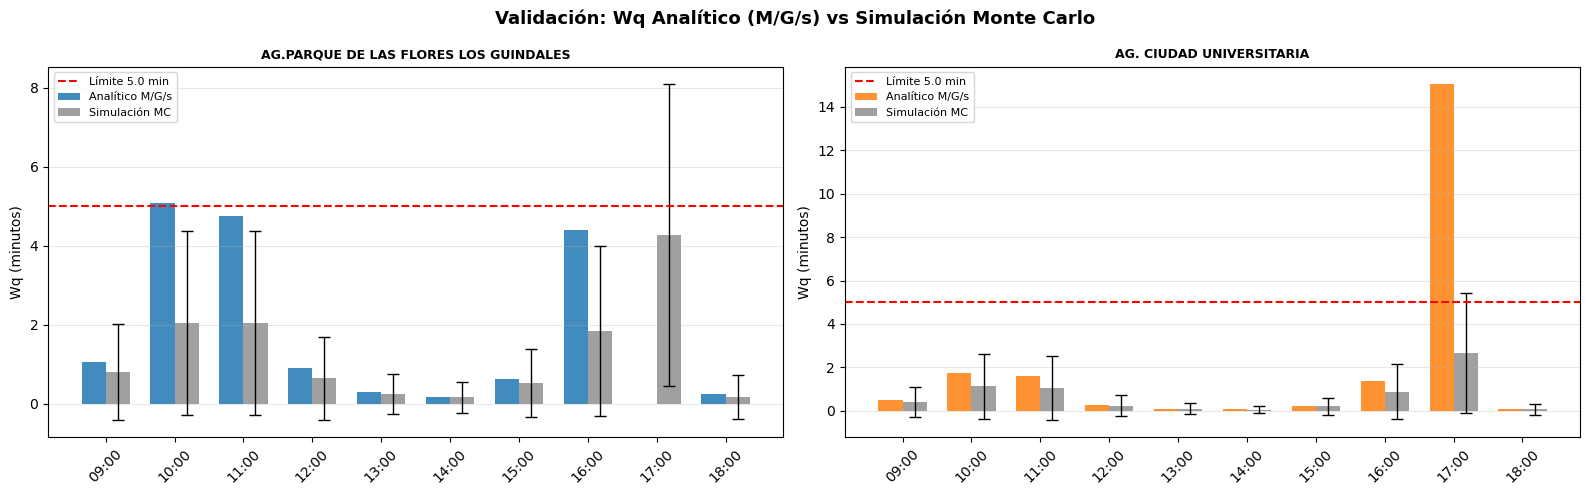

✅ Gráfico guardado: sim_vs_analitico.png


In [15]:
# Gráfico: Analítico vs Simulación
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Validación: Wq Analítico (M/G/s) vs Simulación Monte Carlo', fontsize=13, fontweight='bold')

for ax, agencia, color in zip(axes, agencias, COLORES):
    sub   = res[res['agencia'] == agencia].copy()
    horas = [h[:5] for h in sub['hora']]
    x     = np.arange(len(horas))
    w     = 0.35

    ax.bar(x - w/2, sub['mgs_Wq_m'],           width=w, label='Analítico M/G/s', color=color, alpha=0.85)
    ax.bar(x + w/2, sub['sim_act_sim_Wq_m'],   width=w, label='Simulación MC',   color='gray',  alpha=0.75)
    ax.errorbar(x + w/2, sub['sim_act_sim_Wq_m'],
                yerr=sub['sim_act_sim_Wq_std'], fmt='none', color='black', capsize=4, linewidth=1)
    ax.axhline(WQ_MAX_MIN, color='red', linestyle='--', lw=1.5, label=f'Límite {WQ_MAX_MIN} min')
    ax.set_title(agencia[:40], fontsize=9, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(horas, rotation=45)
    ax.set_ylabel('Wq (minutos)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sim_vs_analitico.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado: sim_vs_analitico.png')

## PASO 11 — Análisis de Sensibilidad

In [16]:
ESCENARIOS_LAM = {'λ -20%': -0.20, 'λ -10%': -0.10, 'Base': 0.0, 'λ +10%': 0.10, 'λ +20%': 0.20}

sens_rows = []
for _, row in res.iterrows():
    for esc_name, delta in ESCENARIOS_LAM.items():
        lam_esc = row['lambda'] * (1 + delta)
        opt_esc = optimizar_servidores(lam_esc, row['mu'], row['Cs'], row['Cq'], row['C_s2'])
        if opt_esc:
            m_esc = mms_metricas(lam_esc, row['mu'], opt_esc['s_opt'], row['Cs'], row['Cq'])
            mgs_esc = aplicar_allen_cunneen(m_esc, lam_esc, row['mu'],
                                            opt_esc['s_opt'], row['Cs'], row['Cq'], row['C_s2'])
            sens_rows.append(dict(
                agencia=row['agencia'], hora=row['hora'],
                escenario=esc_name, lambda_esc=round(lam_esc, 2),
                s_opt_esc=opt_esc['s_opt'],
                rho_esc=round(opt_esc['rho_opt'], 4),
                Wq_m_esc=round(mgs_esc['mgs_Wq_m'], 3),
                CT_esc=round(mgs_esc['mgs_CT'], 2)
            ))

df_sens = pd.DataFrame(sens_rows)
print('=== Análisis de Sensibilidad (λ ±10%, ±20%) ===')
print(df_sens.groupby(['agencia','escenario'])[['s_opt_esc','rho_esc','Wq_m_esc','CT_esc']].mean().round(3))

=== Análisis de Sensibilidad (λ ±10%, ±20%) ===
                                                 s_opt_esc  rho_esc  Wq_m_esc   CT_esc
agencia                               escenario                                       
AG. CIUDAD UNIVERSITARIA              Base          5.9000   0.6490    0.6460 185.7230
                                      λ +10%        6.7000   0.6260    0.3920 201.8650
                                      λ +20%        6.8000   0.6760    0.5870 218.2400
                                      λ -10%        5.6000   0.6170    0.5520 169.0290
                                      λ -20%        5.2000   0.5850    0.4550 152.2650
AG.PARQUE DE LAS FLORES LOS GUINDALES Base          5.8000   0.6170    0.5190 187.3720
                                      λ +10%        6.2000   0.6340    0.4950 203.9790
                                      λ +20%        6.7000   0.6390    0.4400 220.0640
                                      λ -10%        5.2000   0.6150    0.5670 170.

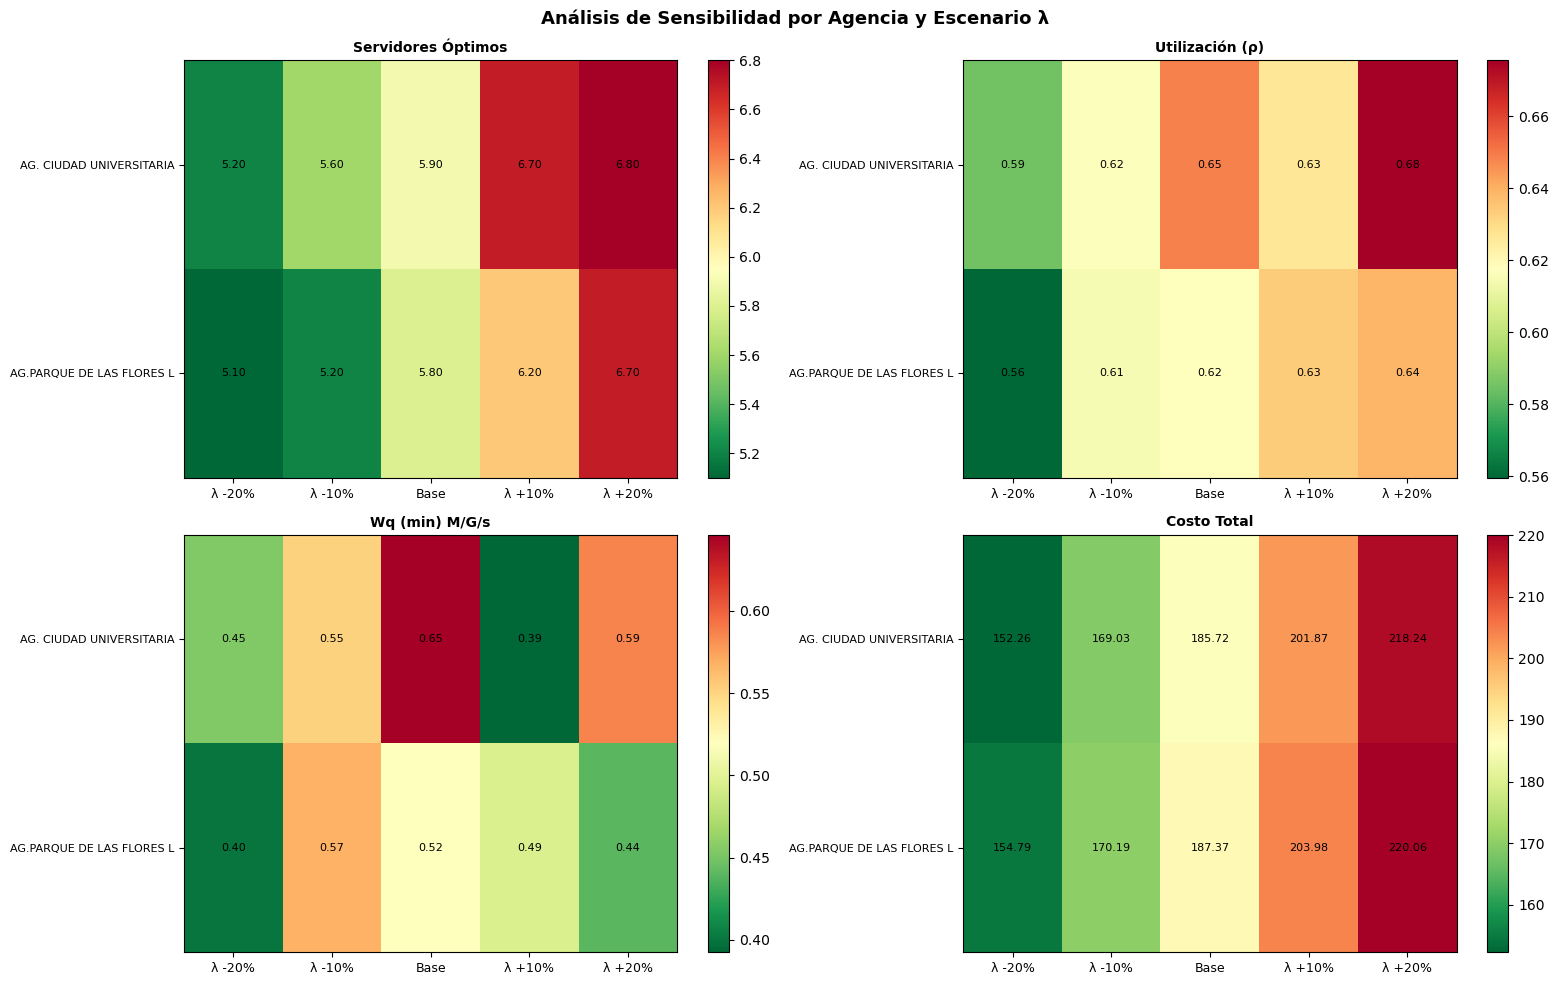

✅ Gráfico guardado: sensibilidad.png


In [17]:
# Heatmap sensibilidad
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análisis de Sensibilidad por Agencia y Escenario λ', fontsize=13, fontweight='bold')

metricas_map = [
    ('s_opt_esc',   'Servidores Óptimos', axes[0,0]),
    ('rho_esc',     'Utilización (ρ)',     axes[0,1]),
    ('Wq_m_esc',    'Wq (min) M/G/s',    axes[1,0]),
    ('CT_esc',      'Costo Total',         axes[1,1]),
]

for metrica, titulo, ax in metricas_map:
    pivot = df_sens.groupby(['agencia','escenario'])[metrica].mean().unstack('escenario')
    pivot = pivot[list(ESCENARIOS_LAM.keys())]
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels([a[:25] for a in pivot.index], fontsize=8)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('sensibilidad.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado: sensibilidad.png')

## PASO 12 — Output Final: Nivel por Hora

In [18]:
def decision_hora(row):
    s_act = row['servidores']
    s_opt = row.get('s_opt', np.nan)
    if np.isnan(s_opt): return '⚠️ SIN DATOS'
    if s_opt > s_act:   return '🔴 CONTRATAR'
    if s_opt < s_act:   return '🟢 REDUCIR'
    return '🟡 MANTENER'

def cumplimiento(row):
    wq = row.get('mgs_Wq_m', np.nan)
    rho = row.get('mms_rho', np.nan)
    if np.isnan(wq): return '❓ SIN DATOS'
    if wq <= WQ_MAX_MIN and rho <= RHO_MAX: return '✅ OK'
    return '❌ NO OK'

output_hora = res[['agencia','hora','lambda','servidores','s_opt',
                    'mms_rho','mms_Wq_m','mgs_Wq_m',
                    'mms_CT','CT_opt']].copy()

output_hora.columns = ['agencia','hora','λ','s_actual','s_óptimo',
                        'ρ','Wq_MMs(min)','Wq_MGs(min)',
                        'CT_actual','CT_óptimo']

output_hora['cumplimiento'] = res.apply(cumplimiento, axis=1)
output_hora['decisión']     = res.apply(decision_hora, axis=1)
output_hora['ahorro_hora']  = (output_hora['CT_actual'] - output_hora['CT_óptimo']).round(2)

print('=== OUTPUT FINAL — NIVEL POR HORA ===')
print(output_hora.to_string(index=False))

output_hora.to_csv('output_por_hora.csv', index=False, float_format='%.4f')
print('\n✅ Guardado: output_por_hora.csv')

=== OUTPUT FINAL — NIVEL POR HORA ===
                              agencia                hora       λ  s_actual  s_óptimo      ρ  Wq_MMs(min)  Wq_MGs(min)  CT_actual  CT_óptimo cumplimiento    decisión  ahorro_hora
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000         5         6 0.7149       1.1974       1.0509   193.2492   186.1477         ✅ OK 🔴 CONTRATAR       7.1000
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200         5         7 0.8849       5.5974       5.0765   342.0081   224.8762      ❌ NO OK 🔴 CONTRATAR     117.1300
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000         5         7 0.8770       5.1712       4.7612   326.4038   223.4145      ❌ NO OK 🔴 CONTRATAR     102.9900
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800         5         5 0.6730       0.9543       0.8977   178.8996   177.7812         ✅ OK  🟡 MANTENER       1.1200
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000  

## PASO 13 — Output Final: Nivel por Turno

In [19]:
print('=== OUTPUT FINAL — NIVEL POR TURNO ===')
print(df_turnos.to_string(index=False))

df_turnos.to_csv('output_por_turno.csv', index=False, float_format='%.4f')
print('\n✅ Guardado: output_por_turno.csv')

# Resumen ejecutivo
print('\n=== RESUMEN EJECUTIVO ===')
for _, row in df_turnos.iterrows():
    print(f"\n📍 {row['agencia'][:30]} | {row['turno']}")
    print(f"   Servidores: actual={row['s_actual']} → óptimo={row['s_opt_turno']}  {row['decision']}")
    print(f"   Wq promedio: {row['Wq_prom_mgs']:.2f} min | ρ promedio: {row['rho_prom']:.3f}")
    print(f"   CT actual: S/.{row['CT_actual_turno']:.2f} → óptimo: S/.{row['CT_opt_turno']:.2f}")
    print(f"   Ahorro estimado: S/.{row['ahorro']:.2f}")

=== OUTPUT FINAL — NIVEL POR TURNO ===
                              agencia           turno  n_horas  lambda_pond  mu_pond  s_actual  s_opt_turno  Wq_prom_mgs  rho_prom  CT_actual_turno  CT_opt_turno    ahorro    decision
             AG. CIUDAD UNIVERSITARIA Turno 1 (09-14)        5      53.1700  13.4500         6            6       0.8530    0.6590         995.6200      995.6200    0.0000  🟡 MANTENER
             AG. CIUDAD UNIVERSITARIA Turno 2 (14-18)        5      46.7900  12.5800         6            6       3.3630    0.6270        1334.6400     1334.6400    0.0000  🟡 MANTENER
AG.PARQUE DE LAS FLORES LOS GUINDALES Turno 1 (09-14)        5      49.6000  13.4800         5            6       0.5260    0.6140        1156.6600      979.1400  177.5200 🔴 CONTRATAR
AG.PARQUE DE LAS FLORES LOS GUINDALES Turno 2 (14-18)        5      44.7400  12.8400         5            6       1.2040    0.5870         744.7900     1061.8400 -317.0500 🔴 CONTRATAR

✅ Guardado: output_por_turno.csv

=== RE

## PASO 14 — Visualizaciones Finales

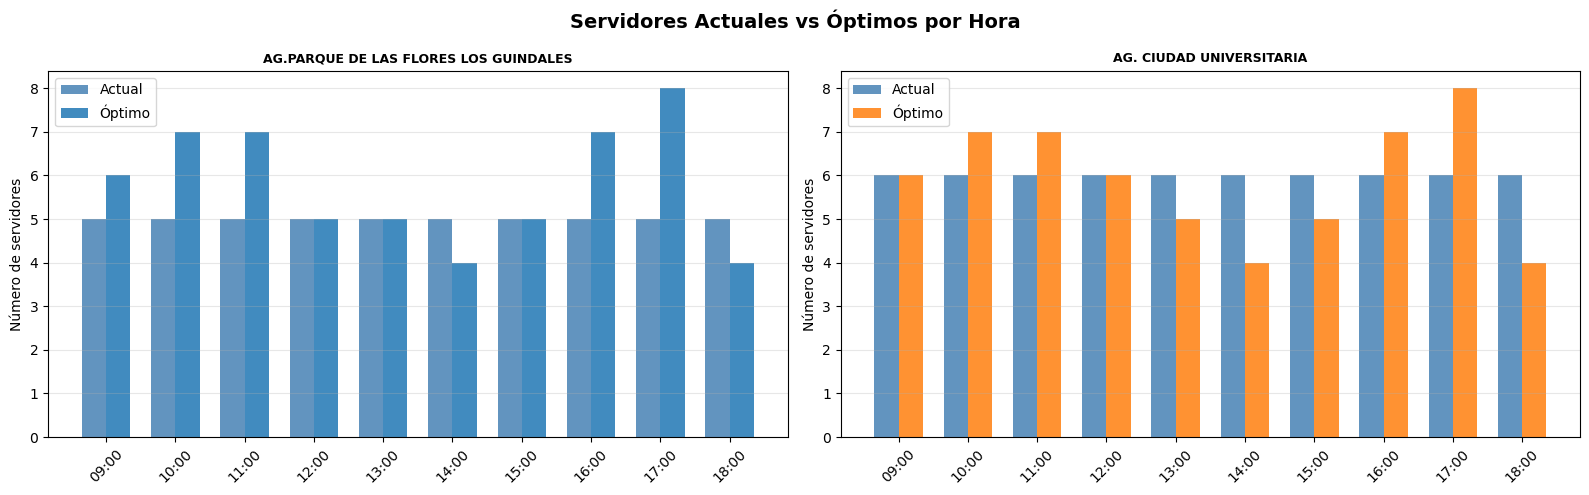

In [20]:
# Gráfico 1: Servidores actuales vs óptimos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Servidores Actuales vs Óptimos por Hora', fontsize=14, fontweight='bold')

for ax, agencia, color in zip(axes, agencias, COLORES):
    sub   = res[res['agencia'] == agencia].copy()
    horas = [h[:5] for h in sub['hora']]
    x     = np.arange(len(horas))
    w     = 0.35
    ax.bar(x - w/2, sub['servidores'], width=w, label='Actual',  color='steelblue', alpha=0.85)
    ax.bar(x + w/2, sub['s_opt'],      width=w, label='Óptimo',  color=color,       alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(horas, rotation=45)
    ax.set_title(agencia[:40], fontsize=9, fontweight='bold')
    ax.set_ylabel('Número de servidores')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('servidores_opt.png', dpi=130, bbox_inches='tight')
plt.show()

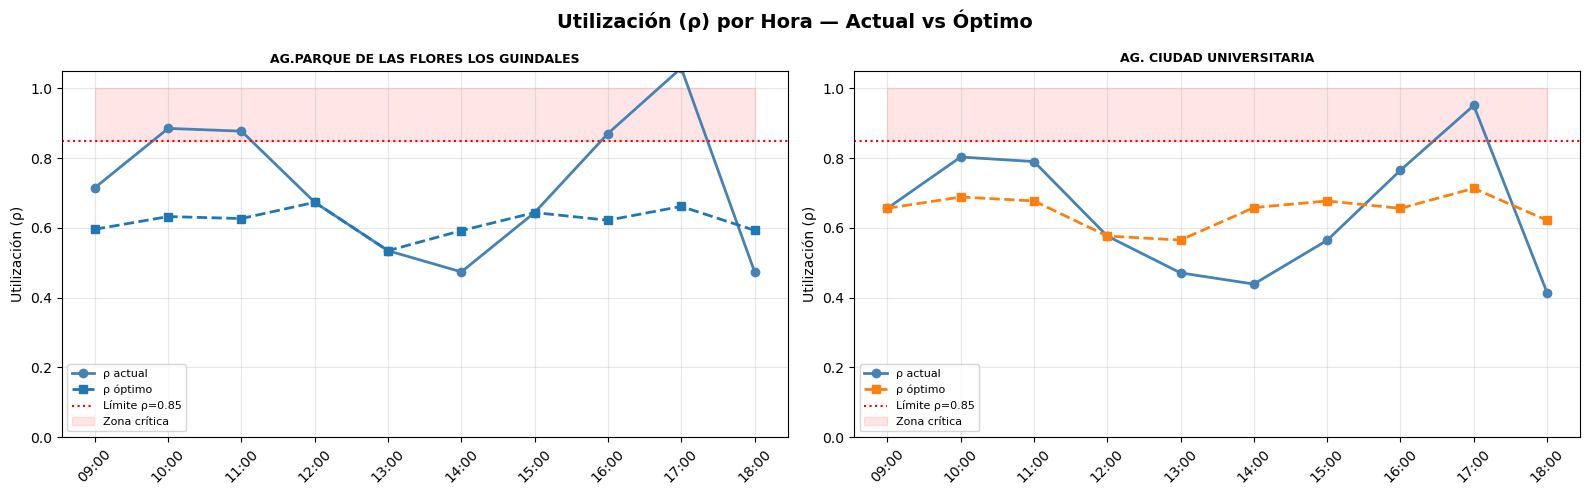

In [21]:
# Gráfico 2: Utilización (ρ) y límite operativo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Utilización (ρ) por Hora — Actual vs Óptimo', fontsize=14, fontweight='bold')

for ax, agencia, color in zip(axes, agencias, COLORES):
    sub   = res[res['agencia'] == agencia].copy()
    horas = [h[:5] for h in sub['hora']]
    x     = np.arange(len(horas))

    ax.plot(x, sub['mms_rho'],  marker='o', color='steelblue', label='ρ actual',  lw=2)
    ax.plot(x, sub['rho_opt'],  marker='s', color=color,       label='ρ óptimo',  lw=2, linestyle='--')
    ax.axhline(RHO_MAX, color='red', linestyle=':', lw=1.5, label=f'Límite ρ={RHO_MAX}')
    ax.fill_between(x, RHO_MAX, 1.0, alpha=0.1, color='red', label='Zona crítica')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x); ax.set_xticklabels(horas, rotation=45)
    ax.set_title(agencia[:40], fontsize=9, fontweight='bold')
    ax.set_ylabel('Utilización (ρ)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('utilizacion.png', dpi=130, bbox_inches='tight')
plt.show()

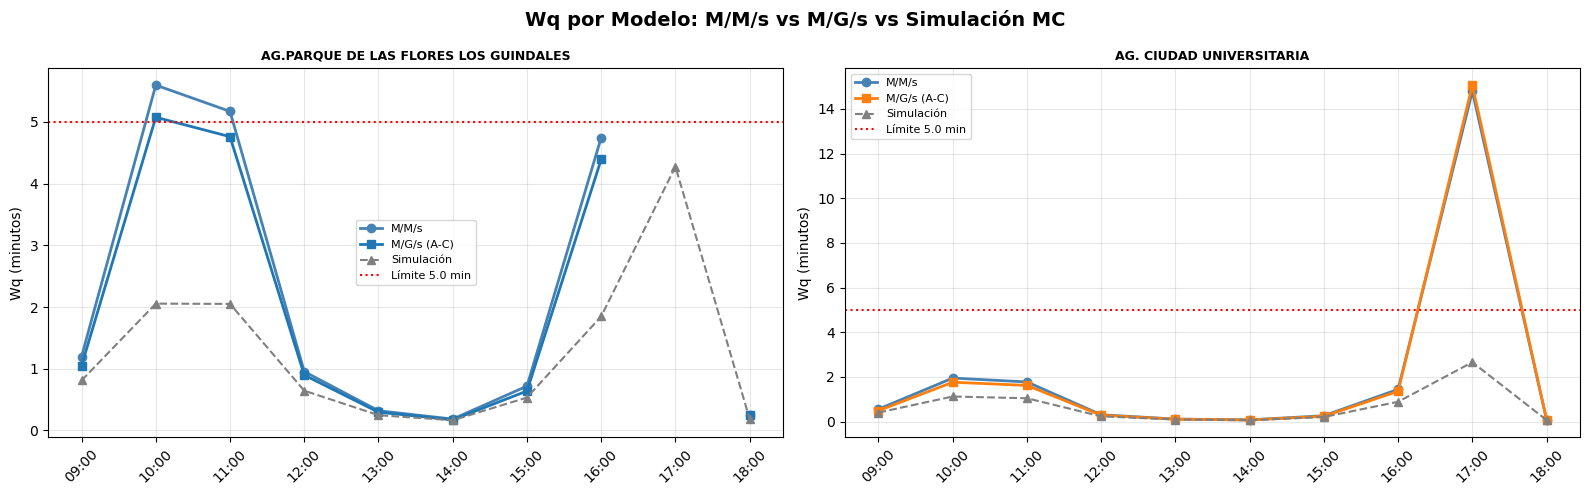

In [22]:
# Gráfico 3: Wq M/M/s vs M/G/s vs Simulación
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Wq por Modelo: M/M/s vs M/G/s vs Simulación MC', fontsize=14, fontweight='bold')

for ax, agencia, color in zip(axes, agencias, COLORES):
    sub   = res[res['agencia'] == agencia].copy()
    horas = [h[:5] for h in sub['hora']]
    x     = np.arange(len(horas))

    ax.plot(x, sub['mms_Wq_m'],           marker='o', label='M/M/s',       color='steelblue', lw=2)
    ax.plot(x, sub['mgs_Wq_m'],           marker='s', label='M/G/s (A-C)', color=color,       lw=2)
    ax.plot(x, sub['sim_act_sim_Wq_m'],   marker='^', label='Simulación',   color='gray',      lw=1.5, linestyle='--')
    ax.axhline(WQ_MAX_MIN, color='red', linestyle=':', lw=1.5, label=f'Límite {WQ_MAX_MIN} min')
    ax.set_xticks(x); ax.set_xticklabels(horas, rotation=45)
    ax.set_title(agencia[:40], fontsize=9, fontweight='bold')
    ax.set_ylabel('Wq (minutos)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('wq_comparativo.png', dpi=130, bbox_inches='tight')
plt.show()

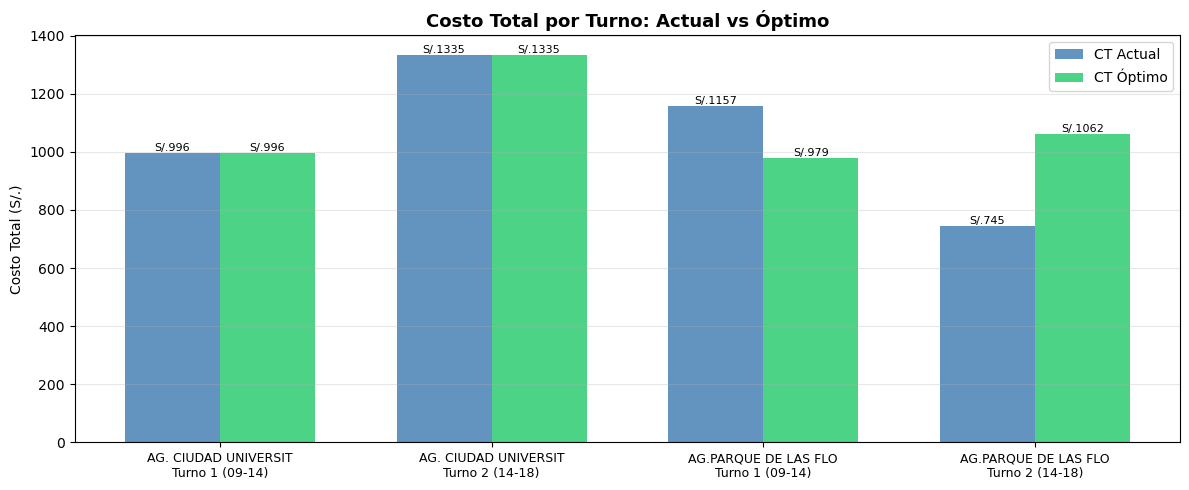


✅ Todos los gráficos guardados


In [23]:
# Gráfico 4: Costo Total — actual vs óptimo por turno
fig, ax = plt.subplots(figsize=(12, 5))
labels  = [f"{r['agencia'][:20]}\n{r['turno']}" for _, r in df_turnos.iterrows()]
x       = np.arange(len(labels))
w       = 0.35

b1 = ax.bar(x - w/2, df_turnos['CT_actual_turno'], width=w, label='CT Actual',  color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, df_turnos['CT_opt_turno'],    width=w, label='CT Óptimo',  color='#2ecc71',   alpha=0.85)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'S/.{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'S/.{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Costo Total (S/.)'); ax.set_title('Costo Total por Turno: Actual vs Óptimo', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('costo_turno.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n✅ Todos los gráficos guardados')

---
## ✅ Resumen del Modelo v4

| Componente | Descripción |
|---|---|
| **M/M/s** | Modelo base por hora con restricciones ρ ≤ 0.85 y Wq ≤ 5 min |
| **Allen-Cunneen** | Extensión M/G/s con C_s² ponderado por mezcla de operaciones |
| **Optimización** | Búsqueda exhaustiva del s óptimo minimizando CT_ajustado |
| **Turnos** | Consolidación T1 (09-14) y T2 (14-18) con λ, μ, C_s² ponderados |
| **Monte Carlo** | Validación con llegadas Poisson y servicios Gamma (3,000 réplicas) |
| **Sensibilidad** | λ ±10% y ±20% sobre servidores, Wq y CT |
| **Outputs** | CSV por hora + por turno + decisiones CONTRATAR/REDUCIR/MANTENER |